In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install catboost optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 41.3 MB/s eta 0:00:00


In [3]:
import optuna
import os
import pandas as pd
import numpy as np
from catboost import CatBoost, Pool

In [4]:
DATA_DIR = "/content/drive/MyDrive/Colab Notebooks"

df_train = pd.read_parquet(f"{DATA_DIR}/train_fe.parquet")
df_val   = pd.read_parquet(f"{DATA_DIR}/val_fe.parquet")
df_test  = pd.read_parquet(f"{DATA_DIR}/test_fe.parquet")

print(f"train: {df_train.shape}, val: {df_val.shape}, test: {df_test.shape}")

train: (4215569, 63), val: (742778, 63), test: (4959183, 58)


In [5]:
df_train = df_train.sort_values('srch_id').reset_index(drop=True)
df_val   = df_val.sort_values('srch_id').reset_index(drop=True)
df_test  = df_test.sort_values('srch_id').reset_index(drop=True)

In [8]:
exclude_cols = [
    "srch_id",
    "prop_id",
    "relevance",
    "date_time",
    "click_bool",
    "booking_bool",
    "gross_bookings_usd",
    "position",
]
features = [c for c in df_train.columns if c not in exclude_cols]

X_train, y_train = df_train[features], df_train["relevance"]
X_val, y_val = df_val[features], df_val["relevance"]
X_test = df_test[features]

cat_features = [
    "site_id",
    "visitor_location_country_id",
    "prop_country_id",
    "srch_destination_id",
]
cat_features = [c for c in cat_features if c in features]

print(f"Features: {len(features)}, categorical: {cat_features}")

Features: 55, categorical: ['site_id', 'visitor_location_country_id', 'prop_country_id', 'srch_destination_id']


In [9]:
train_pool = Pool(
    data=X_train,
    label=y_train,
    group_id=df_train['srch_id'],
    cat_features=cat_features,
)
val_pool = Pool(
    data=X_val,
    label=y_val,
    group_id=df_val['srch_id'],
    cat_features=cat_features,
)
test_pool = Pool(
    data=X_test,
    cat_features=cat_features,
)

In [10]:
base_params = {
    'loss_function':  'YetiRank',
    'eval_metric':    'NDCG:top=5;type=Exp',
    'custom_metric':  ['NDCG:top=5;type=Exp'],
    'iterations':     5000,
    'random_seed':    42,
    'task_type':      'GPU',
    'verbose':        500,
    'use_best_model': True,
    'od_type':        'Iter',
    'od_wait':        200,
}

N_TRIALS = 15


def extract_best_ndcg(model):
    """Pull the type=Exp NDCG specifically. CatBoost auto-tracks the default
    type=Base alongside our custom Exp metric, and Base scores higher than Exp
    on this data — grabbing the wrong one inflates the result.
    """
    er = model.get_evals_result()
    candidates = []
    for split, metrics in er.items():
        if split == 'learn':
            continue
        for metric_name, history in metrics.items():
            if 'NDCG' in metric_name:
                candidates.append((metric_name, max(history)))
    for name, val in candidates:
        if 'Exp' in name:
            return val
    return candidates[0][1] if candidates else float('nan')


def objective(trial):
    hp = {
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 0.1, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
    }
    params = {**base_params, **hp}
    model = CatBoost(params)
    model.fit(train_pool, eval_set=val_pool)
    score = extract_best_ndcg(model)
    trial.set_user_attr('best_iteration', model.best_iteration_)
    trial.set_user_attr('model', model)
    return score


study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
)
study.optimize(objective, n_trials=N_TRIALS, gc_after_trial=True)

best_trial = study.best_trial
best_params = {**base_params, **best_trial.params}
best_model = best_trial.user_attrs['model']
best_ndcg = best_trial.value
print(f"\nBest NDCG@5 (Exp) = {best_ndcg:.4f}")
print(f"Best params: {best_trial.params}")
print(f"Best iteration: {best_trial.user_attrs['best_iteration']}")
print(f"Trials completed: {len(study.trials)}")

[I 2026-05-13 19:43:14,480] A new study created in memory with name: no-name-87bd17b4-472d-40c3-9875-2f8251975999


Groupwise loss function. OneHotMaxSize set to 10


Default metric period is 5 because NDCG is/are not implemented for GPU
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric NDCG:top=5;type=Exp is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric NDCG:top=5;type=Exp is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	test: 0.2374904	best: 0.2374904 (0)	total: 143ms	remaining: 11m 53s
500:	test: 0.3903890	best: 0.3904555 (487)	total: 54.3s	remaining: 8m 7s
1000:	test: 0.3974653	best: 0.3975645 (993)	total: 1m 48s	remaining: 7m 14s
1500:	test: 0.4002510	best: 0.4004075 (1482)	total: 2m 43s	remaining: 6m 20s
2000:	test: 0.4016779	best: 0.4017796 (1946)	total: 3m 37s	remaining: 5m 26s
2500:	test: 0.4027540	best: 0.4028480 (2446)	total: 4m 31s	remaining: 4m 31s
3000:	test: 0.4040201	best: 0.4040747 (2999)	total: 5m 26s	remaining: 3m 37s
3500:	test: 0.4049451	best: 0.4049451 (3500)	total: 6m 20s	remaining: 2m 43s
bestTest = 0.4055756754
bestIteration = 3722
Shrink model to first 3723 iterations.


[I 2026-05-13 19:50:34,796] Trial 0 finished with value: 0.4055756754312342 and parameters: {'depth': 6, 'learning_rate': 0.2536999076681772, 'l2_leaf_reg': 5.395030966670228, 'random_strength': 1.5751320499779735, 'bagging_temperature': 0.15601864044243652}. Best is trial 0 with value: 0.4055756754312342.


...

Groupwise loss function. OneHotMaxSize set to 10


Default metric period is 5 because NDCG is/are not implemented for GPU
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric NDCG:top=5;type=Exp is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric NDCG:top=5;type=Exp is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	test: 0.2660418	best: 0.2660418 (0)	total: 149ms	remaining: 12m 22s
500:	test: 0.3877222	best: 0.3878995 (492)	total: 59.6s	remaining: 8m 54s
1000:	test: 0.3938090	best: 0.3939748 (993)	total: 1m 59s	remaining: 7m 56s
1500:	test: 0.3974172	best: 0.3974172 (1500)	total: 2m 59s	remaining: 6m 57s
2000:	test: 0.3998213	best: 0.3998627 (1997)	total: 3m 59s	remaining: 5m 58s
2500:	test: 0.4015694	best: 0.4016112 (2476)	total: 4m 59s	remaining: 4m 58s
3000:	test: 0.4025016	best: 0.4026595 (2978)	total: 5m 59s	remaining: 3m 59s
3500:	test: 0.4037971	best: 0.4037971 (3500)	total: 6m 59s	remaining: 2m 59s
bestTest = 0.4042807976
bestIteration = 3714
Shrink model to first 3715 iterations.


[I 2026-05-13 21:59:39,920] Trial 14 finished with value: 0.4042807976206176 and parameters: {'depth': 7, 'learning_rate': 0.14728562654282598, 'l2_leaf_reg': 4.951695624904742, 'random_strength': 0.3539728451056158, 'bagging_temperature': 0.3476334304965827}. Best is trial 11 with value: 0.4064815901283401.



Best NDCG@5 (Exp) = 0.4065
Best params: {'depth': 6, 'learning_rate': 0.2835559696877989, 'l2_leaf_reg': 5.158744357929928, 'random_strength': 0.14830989820486237, 'bagging_temperature': 0.0037369778131835264}
Best iteration: 4069
Trials completed: 15


In [11]:
df_all = pd.concat([df_train, df_val], ignore_index=True).sort_values('srch_id').reset_index(drop=True)
X_all = df_all[features]
y_all = df_all['relevance']

all_pool = Pool(
    data=X_all,
    label=y_all,
    group_id=df_all['srch_id'],
    cat_features=cat_features,
)

final_params = {k: v for k, v in best_params.items()
                if k not in ('od_type', 'od_wait', 'use_best_model')}
final_params['iterations'] = best_model.best_iteration_
final_model = CatBoost(final_params)
final_model.fit(all_pool)

Groupwise loss function. OneHotMaxSize set to 10


Default metric period is 5 because NDCG is/are not implemented for GPU
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric NDCG:top=5;type=Exp is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric NDCG:top=5;type=Exp is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	total: 132ms	remaining: 8m 56s
500:	total: 56.1s	remaining: 6m 39s
1000:	total: 1m 52s	remaining: 5m 43s
1500:	total: 2m 48s	remaining: 4m 47s
2000:	total: 3m 44s	remaining: 3m 51s
2500:	total: 4m 40s	remaining: 2m 55s
3000:	total: 5m 36s	remaining: 1m 59s
3500:	total: 6m 32s	remaining: 1m 3s
4000:	total: 7m 28s	remaining: 7.62s
4068:	total: 7m 35s	remaining: 0us


CatBoost(bagging_temperature=0.0037369778131835264, custom_metric=['NDCG:top=5;type=Exp'], depth=6, eval_metric='NDCG:top=5;type=Exp', iterations=4069, l2_leaf_reg=5.158744357929928, learning_rate=0.2835559696877989, loss_function='YetiRank', random_seed=42, random_strength=0.14830989820486237, task_type='GPU', verbose=500)

In [12]:
df_test["predicted_score"] = final_model.predict(test_pool)

submission = df_test.sort_values(["srch_id", "predicted_score"], ascending=[True, False])[
    ["srch_id", "prop_id"]
]

submission.to_csv(f"{DATA_DIR}/submission_catboost.csv", index=False)
print(f"Submission saved: {len(submission)} rows")
submission.head(10)

Submission saved: 4959183 rows


,srch_id,prop_id
23,1,99484
9,1,54937
13,1,28181
5,1,61934
10,1,24194
12,1,34263
27,1,90385
25,1,82231
3,1,50162
4,1,63894


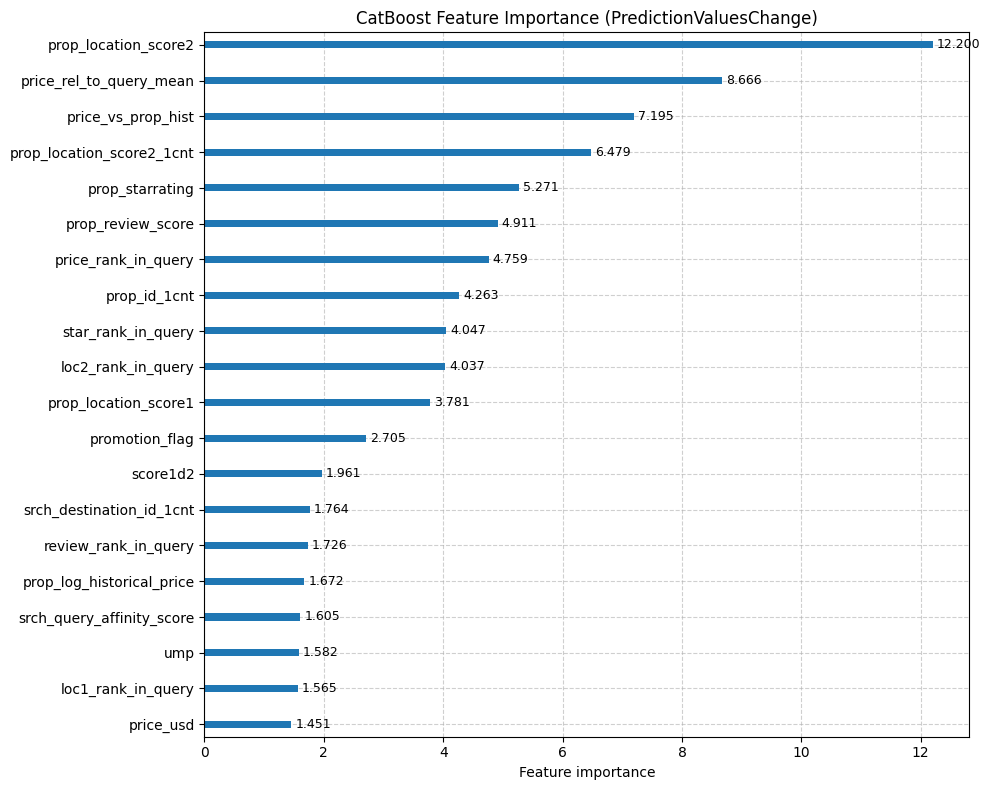

In [13]:
import matplotlib.pyplot as plt

importances = final_model.get_feature_importance(type='PredictionValuesChange')
imp = pd.Series(importances, index=features).sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
imp.plot.barh(ax=ax, width=0.2)
ax.bar_label(ax.containers[0], fmt="%.3f", padding=3, fontsize=9)
ax.grid(axis="both", linestyle="--", alpha=0.6)
ax.set_axisbelow(True)
ax.set_xlabel("Feature importance")
ax.set_title("CatBoost Feature Importance (PredictionValuesChange)")
plt.tight_layout()
plt.savefig(f"{DATA_DIR}/catboost_feature_importance.pdf")
plt.show()